## Customer Churn Analysis
This notebook presents an analysis of user behavior data from a streaming service, with the goal of predicting customer churn using machine learning.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("netflix_customer_churn.csv")
data.head(10)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
5,d8079475-5be7-47e9-8782-ceb7ff61395e,58,Female,Standard,13.80,26,Oceania,Mobile,13.99,0,Debit Card,3,0.51,Action
6,8e63450a-13d6-4e83-bbb5-6aebde9152cb,48,Other,Basic,13.83,20,Asia,TV,8.99,0,Gift Card,5,0.66,Romance
7,02387681-8c42-462a-807a-de0168c73b38,51,Male,Basic,14.30,56,Europe,Mobile,8.99,1,Gift Card,1,0.25,Action
8,0bcaad0c-545c-4ee1-85a6-75e165f39361,45,Other,Basic,9.98,10,Asia,Mobile,8.99,0,PayPal,3,0.91,Romance
9,eae6439e-8cdf-4258-ab49-c493925b927a,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama


#### **1. Understanding the dataset**
The first step is to understand the dataset.

In [15]:
data.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

churned
1    2515
0    2485
Name: count, dtype: int64


C:\Users\matte\AppData\Local\Temp\ipykernel_71108\1906165726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churned', data=data, palette='bright')


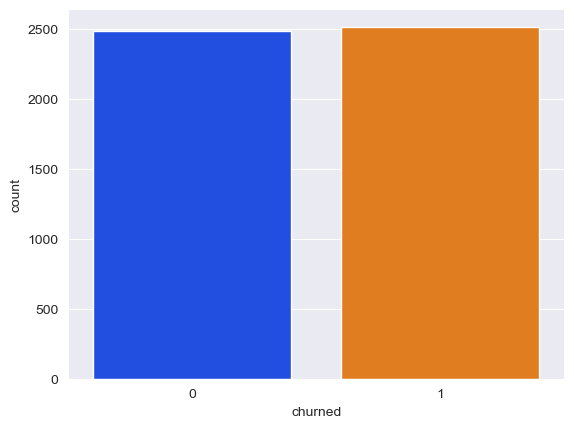

In [14]:
print(data['churned'].value_counts())
sns.countplot(x='churned', data=data, palette='bright')
plt.show()

As we can see, the feature is well-balanced, so we will not risk introducing bias toward either class during training. 

#### **2. Data Preprocessing**
##### Wrangling incorrect features
Label encoding will be applied to the categorical features to convert their categorical values into numeric form.

In [19]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
categorical_cols = ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
for col in categorical_cols: 
    data[col] = labelencoder.fit_transform(data[col])

##### Data Splitting

In [21]:
from sklearn.model_selection import train_test_split

X = data.drop(columns = ['churned', 'customer_id'])
y = data['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **3. Model Training and Evaluation**
To train our model we use Random Forest Classifier. It is an ensemble learning method that combines the results of multiple decision trees to make a final prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifierEW